# Linear Regression

**Import Libraries & Load Data**

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import joblib
import mlflow
import mlflow.sklearn
import mlflow.pytorch

# Enable autologging for scikit-learn
mlflow.sklearn.autolog()

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Iris.csv')

# Display dataset statistics
print("\nDataset Summary Statistics:")
print(df.describe())
print("\nTarget Class Distribution (Species):")
print(df['Species'].value_counts())


Dataset Summary Statistics:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000

Target Class Distribution (Species):
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


**Prepare Data & Train Model**

In [19]:
import mlflow
# Point to the background MLflow server
mlflow.set_tracking_uri("http://localhost:5000")

# Define features (X) and target variable (y)
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalWidthCm']]
y = df['PetalLengthCm']

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

with mlflow.start_run(run_name="Linear_Regression_Iris"):
    # Initialize and train the Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nLinear Regression Model Performance Metrics:")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

2026/06/30 16:49:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Linear_Regression_Iris at: http://localhost:5000/#/experiments/0/runs/3c92772a237441dfa68534910c8243f3
🧪 View experiment at: http://localhost:5000/#/experiments/0

Linear Regression Model Performance Metrics:
Model Coefficients: [ 0.72417306 -0.641963    1.46632204]
Model Intercept: -0.2504659324864602
Mean Squared Error (MSE): 0.13
R-squared (R2) Score: 0.96


**Save the Model**

In [11]:
# Persist the trained model for future deployment
joblib.dump(model, '/content/drive/MyDrive/Colab Notebooks/ML - Project/Linear Regression/iris_linear_regression_model.pkl')
print("\nModel successfully saved to: iris_linear_regression_model.pkl")


Model successfully saved to: iris_linear_regression_model.pkl


**Custom Predictions (User Input)**

In [12]:
# Execute prediction function for Linear Regression
# Re-defined here to ensure functionality
def predict_petal_length():
    model = joblib.load('/content/drive/MyDrive/Colab Notebooks/ML - Project/Linear Regression/iris_linear_regression_model.pkl')
    print("\nModel Inference Mode: Linear Regression (Petal Length Prediction)")
    sepal_length = float(input("Enter Sepal Length (cm): "))
    sepal_width = float(input("Enter Sepal Width (cm): "))
    petal_width = float(input("Enter Petal Width (cm): "))

    input_data = [[sepal_length, sepal_width, petal_width]]
    prediction = model.predict(input_data)
    print(f"\nPredicted Petal Length: {prediction[0]:.2f} cm")

predict_petal_length()


Model Inference Mode: Linear Regression (Petal Length Prediction)
Enter Sepal Length (cm): 25
Enter Sepal Width (cm): 25
Enter Petal Width (cm): 25

Predicted Petal Length: 38.46 cm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# K-Nearest Neighbors (KNN)

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import joblib
import mlflow

# Point to the background MLflow server
mlflow.set_tracking_uri("http://localhost:5000")

# Load dataset and prepare features
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Iris.csv')

print("\nDataset Overview:")
print(f"Total Observations: {len(df)}")
print(f"Feature Set: {df.columns.tolist()[1:-1]}")

# Prepare feature matrix and target vector
X = df.iloc[:, 1:-1].values
y = df['Species'].values

# Partition dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling to optimize KNN performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

with mlflow.start_run(run_name="KNN_Iris"):
    # Initialize and train K-Nearest Neighbors classifier
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

# Execute classification on test data
y_pred = knn.predict(X_test)

# Evaluate classification performance
print("\nKNN Classification Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Serialize model and preprocessing components
joblib.dump(knn, '/content/drive/MyDrive/Colab Notebooks/ML - Project/KNN/iris_knn_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Colab Notebooks/ML - Project/KNN/iris_knn_scaler.pkl')
print("\nArtifacts saved: KNN model and Standard Scaler")

# Function for custom predictions
def predict_species():
    print("\nEnter flower measurements (in cm):")
    sepal_length = float(input("Sepal Length: "))
    sepal_width = float(input("Sepal Width: "))
    petal_length = float(input("Petal Length: "))
    petal_width = float(input("Petal Width: "))

    # Scale inputs using saved scaler
    input_data = scaler.transform([[sepal_length, sepal_width, petal_length, petal_width]])
    prediction = knn.predict(input_data)

    print(f"\nPredicted Species: {prediction[0]}")

# Test prediction
predict_species()


Dataset Overview:
Total Observations: 150
Feature Set: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


2026/06/30 16:49:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run KNN_Iris at: http://localhost:5000/#/experiments/0/runs/4c83803615d648449bb80286969da869
🧪 View experiment at: http://localhost:5000/#/experiments/0

KNN Classification Performance:
Accuracy Score: 100.00%

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Detailed Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Artifacts saved: KNN model and Standard Scaler

Enter flower measurements (in cm):
Sepal Length: 25
Sepal Width: 25
Petal Length: 25
Petal Width: 25

Predicted Species: Iris-virginica


# Decision Tree


Dataset Overview:
Total samples: 150
Features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


2026/06/30 16:48:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


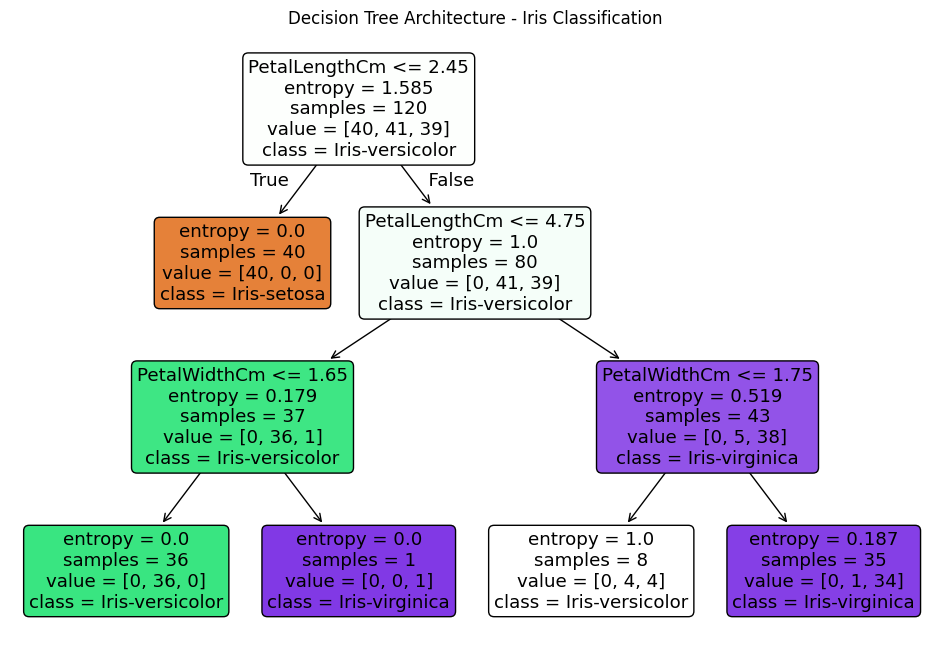

🏃 View run Decision_Tree_Iris at: http://localhost:5000/#/experiments/0/runs/21eb215d4eb64e07a08da72cc1a5debf
🧪 View experiment at: http://localhost:5000/#/experiments/0

Decision Tree Classification Performance:
Accuracy Score: 100.00%

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


['/content/drive/MyDrive/Colab Notebooks/ML - Project/Decision Tree/iris_decision_tree.pkl']

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import joblib
import mlflow

# Point to the background MLflow server started in cell If_yJikoapSB
mlflow.set_tracking_uri("http://localhost:5000")

# Load and describe data
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Iris.csv')
X = df.iloc[:, 1:-1].values
y = df['Species'].values
print("\nDataset Overview:")
print(f"Total samples: {len(df)}")
print(f"Features: {df.columns.tolist()[1:-1]}")

# Training/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

with mlflow.start_run(run_name="Decision_Tree_Iris"):
    # Decision Tree model development
    dtree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
    dtree.fit(X_train, y_train)

    # Prediction and Evaluation
    y_pred = dtree.predict(X_test)

    # Structural Visualization
    fig = plt.figure(figsize=(12, 8))
    plot_tree(dtree, feature_names=df.columns[1:-1], class_names=df['Species'].unique(), filled=True, rounded=True)
    plt.title("Decision Tree Architecture - Iris Classification")

    # This now succeeds because the tracking URI is set to the local server
    mlflow.log_figure(fig, "decision_tree_architecture.png")
    plt.show()

print("\nDecision Tree Classification Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save classification model
joblib.dump(dtree, '/content/drive/MyDrive/Colab Notebooks/ML - Project/Decision Tree/iris_decision_tree.pkl')


In [21]:
# Execute prediction function for Decision Tree
def predict_species_dt():
    import joblib
    # Load the persisted Decision Tree model
    model = joblib.load('/content/drive/MyDrive/Colab Notebooks/ML - Project/Decision Tree/iris_decision_tree.pkl')

    print("\nModel Inference Mode: Decision Tree Classifier")
    try:
        sepal_length = float(input("Enter Sepal Length (cm): "))
        sepal_width = float(input("Enter Sepal Width (cm): "))
        petal_length = float(input("Enter Petal Length (cm): "))
        petal_width = float(input("Enter Petal Width (cm): "))

        input_data = [[sepal_length, sepal_width, petal_length, petal_width]]
        prediction = model.predict(input_data)
        print(f"\nPredicted Species: {prediction[0]}")
    except ValueError:
        print("Invalid input. Please enter numeric values.")

predict_species_dt()


Model Inference Mode: Decision Tree Classifier
Enter Sepal Length (cm): 25
Enter Sepal Width (cm): 25
Enter Petal Length (cm): 25
Enter Petal Width (cm): 25


2026/06/30 16:50:44 WARNING mlflow.sklearn: Unrecognized dataset type <class 'list'>. Dataset logging skipped.



Predicted Species: Iris-virginica


# CNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
import numpy as np
from PIL import Image
import mlflow
import mlflow.pytorch

# --- 1. Load and Preprocess CIFAR-10 Dataset ---
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

# --- 2. Dataset Descriptive Statistics ---
print(f"Training tensor shape: {trainset.data.shape}")
print(f"Test tensor shape: {testset.data.shape}")
print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")
class_names = trainset.classes
print(f"Class labels: {class_names}")

# --- 3. Convolutional Neural Network Architecture ---
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 10)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = nn.ReLU()(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNNModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 4. Model Training and Validation wrapped with MLflow ---
epochs = 1  # Reduced for demonstration of fix
mlflow.set_tracking_uri("http://localhost:5000")

with mlflow.start_run(run_name="CNN_CIFAR10_Fixed"):
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        e_train_loss = running_loss / len(trainloader)
        e_train_acc = 100 * correct / total
        train_loss.append(e_train_loss)
        train_acc.append(e_train_acc)

        model.eval()
        v_loss_sum, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                v_loss_sum += loss.item()
                _, predicted = torch.max(outputs, 1)
                v_total += labels.size(0)
                v_correct += (predicted == labels).sum().item()

        e_val_loss = v_loss_sum / len(testloader)
        e_val_acc = 100 * v_correct / v_total
        val_loss.append(e_val_loss)
        val_acc.append(e_val_acc)

        # MLflow explicit logging
        mlflow.log_metric("train_loss", e_train_loss, step=epoch)
        mlflow.log_metric("train_acc", e_train_acc, step=epoch)
        mlflow.log_metric("val_loss", e_val_loss, step=epoch)
        mlflow.log_metric("val_acc", e_val_acc, step=epoch)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Acc: {e_train_acc:.2f}% | Val Acc: {e_val_acc:.2f}%")

    mlflow.pytorch.log_model(model, "model")

# --- 5. Visualization: Training History ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

# --- 6. Confusion Matrix ---
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for inputs, labels in testloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
# --- 7. Prediction Using Custom Input ---
def predict_custom_image(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
        img_disp = img.copy()
        img = img.resize((32, 32))
        img_tensor = transform(img).unsqueeze(0)

        model.eval()
        with torch.no_grad():
            output = model(img_tensor)
            _, predicted_class = torch.max(output, 1)

        print(f"Predicted Class: {class_names[predicted_class.item()]}")
        plt.imshow(img_disp)
        plt.title(f"Prediction: {class_names[predicted_class.item()]}")
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Error processing image: {e}")

# Example usage
predict_custom_image('/content/drive/MyDrive/Colab Notebooks/0049.png')

# --- 8. Model Preservation ---
torch.save(model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/ML - Project/CNN/cifar10_cnn_model.pth')
print("Model weights persisted successfully.")

  1%|          | 1.70M/170M [00:21<26:20, 107kB/s]

**MLflow**

In [25]:
# Launch the MLflow engine in the background
get_ipython().system_raw("mlflow ui --port 5000 --host 0.0.0.0 &")

# Create a secure tunnel to view your charts right inside Colab
from google.colab import output
output.serve_kernel_port_as_iframe(5000)

<IPython.core.display.Javascript object>